# Pacing and dialogue density

Here, I compute two structural features for every script in the analysis corpus, in a single pass over each parsed file.

**Pacing**: mean words per scene. Computed as total word count divided by the number of lines tagged `S` (scene headings). Lower values mean shorter scenes on average, i.e. faster cutting. Scripts with zero `S` tags go through a recovery pass (see §2b).

**Dialogue density**: proportion of the script that is spoken dialogue. Computed as the word count of lines tagged `D` divided by total word count. Lines tagged `E` (parentheticals) are excluded from the dialogue count. Scripts with zero `D` tags get density = 0 and are flagged but not excluded.

Output goes to `thesis-outputs/pacing_dialogue.json`.

## 1. Paths

In [5]:
import json
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

LOCAL_ROOT    = Path('/Users/derinsavasan/Desktop/parsons-spring/thesis')
SCRIPTS_DIR   = LOCAL_ROOT / 'Movie-Script-Database/scripts/parsed/tagged'
METADATA_PATH = LOCAL_ROOT / 'Movie-Script-Database/scripts/metadata/analysis_corpus_final.json'
OUT_PATH      = LOCAL_ROOT / 'thesis-outputs/pacing_dialogue.json'

corpus = json.loads(METADATA_PATH.read_text())
print(f'Corpus: {len(corpus)} scripts')
print(f'Scripts dir exists: {SCRIPTS_DIR.exists()}')

Corpus: 1627 scripts
Scripts dir exists: True


/Users/derinsavasan/Desktop/parsons-spring/thesis/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Extraction function

One pass over the file. For each line:
- Read the tag prefix (`S:`, `D:`, `E:`, etc.)
- Count words in the content after the prefix toward `total_word_count` for every line
- Increment `scene_count` when the tag is `S`
- Add to `dialogue_word_count` when the tag is `D` (skip `E`)

Lines with no recognised prefix (blank lines, malformed) contribute to total word count but not to scene or dialogue counts.

In [6]:
# Matches the single-letter tag at the start of a line, e.g. "S: ", "D: "
TAG_RE = re.compile(r'^([A-Z]):\s*')

def _word_count(text: str) -> int:
    return len(text.split())


def extract_pacing_dialogue(path: Path) -> dict:
    """
    Single-pass extraction of pacing and dialogue density from a tagged script.

    Returns a dict with:
        scene_count         — number of S-tagged lines
        total_word_count    — words across all lines
        dialogue_word_count — words on D-tagged lines only (E excluded)
        pacing              — total_word_count / scene_count, or None if scene_count == 0
        dialogue_density    — dialogue_word_count / total_word_count, or 0.0 if no D lines
        flags               — list of warning strings
    """
    scene_count         = 0
    total_word_count    = 0
    dialogue_word_count = 0
    flags               = []

    text = path.read_text(encoding='utf-8', errors='replace')

    for line in text.splitlines():
        m = TAG_RE.match(line)
        if m:
            tag     = m.group(1)
            content = line[m.end():]
        else:
            tag     = None
            content = line

        wc = _word_count(content)
        total_word_count += wc

        if tag == 'S':
            scene_count += 1
        elif tag == 'D':
            dialogue_word_count += wc
        # E (parentheticals) intentionally excluded from dialogue count

    # Pacing
    if scene_count == 0:
        pacing = None
        flags.append('no_scene_headings')
    else:
        pacing = total_word_count / scene_count

    # Dialogue density
    if dialogue_word_count == 0:
        flags.append('no_dialogue')

    if total_word_count == 0:
        dialogue_density = 0.0
        flags.append('empty_file')
    else:
        dialogue_density = dialogue_word_count / total_word_count

    return {
        'scene_count':         scene_count,
        'total_word_count':    total_word_count,
        'dialogue_word_count': dialogue_word_count,
        'pacing':              pacing,
        'dialogue_density':    dialogue_density,
        'flags':               flags,
    }

## 2b. Scene-heading recovery for no-S scripts

Inspection shows that scripts with zero `S` tags are OCR'd scans where scene headings were either (a) tagged as `N` because they use `INT:` / `EXT:` with a colon instead of a period, or (b) merged mid-line into an `N` block by the scanner. The parser's `S`-detection relies on the period form so it missed all of them.

Recovery strategy: for each `N`-tagged line, count occurrences of `INT[.:]` or `EXT[.:]` as a proxy for scene headings. Each hit is treated as one scene. This is stored as `recovered_scene_count` and kept separate from parser-confirmed `scene_count`. Pacing computed from the recovered count is stored as `recovered_pacing` and flagged `recovered_scenes` so downstream analysis can filter or weight accordingly.

In [10]:
# Matches INT. INT: EXT. EXT: INT/EXT. EXT/INT. etc. — anywhere in a line
SCENE_HDR_RE = re.compile(r'\b(?:INT|EXT)(?:/(?:INT|EXT))?[\.:]', re.IGNORECASE)

# Tags whose content we scan for embedded scene headings.
# N: action lines (most common), D: lines where the parser mislabeled action as
# dialogue (seen in The Matrix, Inception, Gone Girl), M: lines where the parser
# collapsed everything into metadata (e.g. The Big Lebowski). Untagged lines are
# also included. E: (parentheticals) is skipped — no scene headings live there.
RECOVERY_TAGS = {'N', 'D', 'M'}


def recover_scene_count(path: Path) -> int:
    """
    Count scene headings in a script where the parser assigned zero S tags.
    Scans N, D, M, and untagged lines for INT./INT:/EXT./EXT: patterns.
    Each regex match counts as one scene heading.
    """
    count = 0
    for line in path.read_text(encoding='utf-8', errors='replace').splitlines():
        m = TAG_RE.match(line)
        tag = m.group(1) if m else None
        if tag in RECOVERY_TAGS or tag is None:
            content = line[m.end():] if m else line
            count += len(SCENE_HDR_RE.findall(content))
    return count

## 3. Run over corpus

In [11]:
results = []
missing = []

for entry in tqdm(corpus, desc='Scripts'):
    slug        = entry['slug']
    imdb_id     = entry.get('tmdb', {}).get('imdb_id')
    script_path = SCRIPTS_DIR / f'{slug}_parsed.txt'

    if not script_path.exists():
        missing.append(slug)
        continue

    features = extract_pacing_dialogue(script_path)

    results.append({
        'slug':                slug,
        'imdb_id':             imdb_id,
        'scene_count':         features['scene_count'],
        'total_word_count':    features['total_word_count'],
        'dialogue_word_count': features['dialogue_word_count'],
        'pacing':              features['pacing'],
        'dialogue_density':    features['dialogue_density'],
        'recovered_scene_count': None,
        'recovered_pacing':      None,
        'flags':               features['flags'],
    })

no_scenes   = [r for r in results if 'no_scene_headings' in r['flags']]
no_dialogue = [r for r in results if 'no_dialogue'       in r['flags']]

print(f'Processed : {len(results)} scripts')
print(f'Missing   : {len(missing)} scripts')
print(f'No S tags : {len(no_scenes)}  (will attempt recovery)')
print(f'No D tags : {len(no_dialogue)}  (density recorded as 0)')
if missing:
    print('Missing slugs:', missing)

Scripts: 100%|██████████| 1627/1627 [00:02<00:00, 573.39it/s]

Processed : 1627 scripts
Missing   : 0 scripts
No S tags : 177  (will attempt recovery)
No D tags : 4  (density recorded as 0)


## 3b. Run scene-heading recovery

In [12]:
recovered  = 0
still_zero = []
to_recover = [r for r in results if 'no_scene_headings' in r['flags']]

for r in tqdm(to_recover, desc='Recovery'):
    path = SCRIPTS_DIR / f"{r['slug']}_parsed.txt"
    rc   = recover_scene_count(path)

    r['recovered_scene_count'] = rc

    if rc > 0:
        r['recovered_pacing'] = r['total_word_count'] / rc
        r['flags'].append('recovered_scenes')
        recovered += 1
    else:
        r['flags'].append('unrecoverable_pacing')
        still_zero.append(r['slug'])

print(f'Recovery attempted   : {len(to_recover)} scripts')
print(f'Successfully recovered: {recovered}')
print(f'Still zero           : {len(still_zero)}')
if still_zero:
    print('  Unrecoverable:', still_zero)

Recovery: 100%|██████████| 177/177 [00:00<00:00, 353.41it/s]

Recovery attempted   : 177 scripts
Successfully recovered: 142
Still zero           : 35
  Unrecoverable: ['the-blues-brothers-1980', 'the-evil-dead-1981', 'the-outsiders-1983', 'once-upon-a-time-in-america-1984', 'out-of-africa-1985', 'tin-men-1987', 'the-big-lebowski-1998', 'the-matrix-1999', 'proof-of-life-2000', 'the-majestic-2001', '8-mile-2002', 'war-of-the-worlds-2005', 'v-for-vendetta-2006', 'ratatouille-2007', 'a-serious-man-2009', 'inglourious-basterds-2009', 'the-white-ribbon-2009', 'another-year-2010', 'true-grit-2010', 'blue-jasmine-2013', 'gravity-2013', 'inside-llewyn-davis-2013', 'mr-turner-2014', 'nightcrawler-2014', 'mad-max-fury-road-2015', 'the-nice-guys-2016', 'the-red-turtle-2016', 'mother-2017', 'roman-j-israel-esq-2017', 'thoroughbreds-2018', 'velvet-buzzsaw-2019', 'underwater-2020', 'glass-onion-a-knives-out-mystery-2022', 'tar-2022', 'saturday-night-2024']


## 4. Save

In [13]:
OUT_PATH.write_text(json.dumps(results, indent=2))
print(f'Saved -> {OUT_PATH}')
print(f'{len(results)} records')

has_pacing = [r for r in results if r['pacing'] is not None or r['recovered_pacing'] is not None]
no_pacing  = [r for r in results if r['pacing'] is None     and r['recovered_pacing'] is None]
print(f'\nPacing coverage:')
print(f'  Parser S tags    : {sum(1 for r in results if r["pacing"] is not None)}')
print(f'  Recovered        : {sum(1 for r in results if r["recovered_pacing"] is not None)}')
print(f'  Total with pacing: {len(has_pacing)} / {len(results)}')
print(f'  Unrecoverable    : {len(no_pacing)}')

Saved -> /Users/derinsavasan/Desktop/parsons-spring/thesis/thesis-outputs/pacing_dialogue.json
1627 records

Pacing coverage:
  Parser S tags    : 1450
  Recovered        : 142
  Total with pacing: 1592 / 1627
  Unrecoverable    : 35


## 5. Sanity check

Distribution of pacing scores and dialogue density across the corpus. Recovered pacing values are overlaid in orange.

--- Pacing (words per scene, parser + recovered) ---
  n      : 1592
  mean   : 10829.0
  median : 7976.8
  std    : 10158.2
  min    : 50.0
  max    : 57444.0

--- Dialogue density (proportion) ---
  n      : 1627
  mean   : 0.830
  median : 0.914
  std    : 0.211
  min    : 0.000
  max    : 0.966


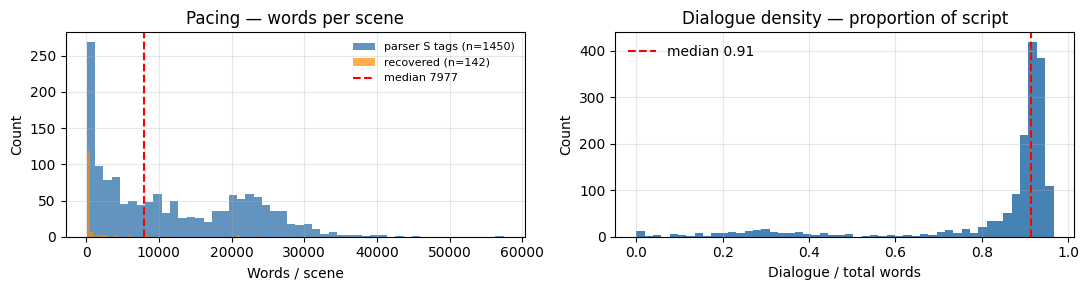

In [14]:
parser_pacing    = [r['pacing']           for r in results if r['pacing'] is not None]
recovered_pacing = [r['recovered_pacing'] for r in results if r['recovered_pacing'] is not None]
all_pacing       = parser_pacing + recovered_pacing
density_vals     = [r['dialogue_density'] for r in results]

print('--- Pacing (words per scene, parser + recovered) ---')
print(f'  n      : {len(all_pacing)}')
print(f'  mean   : {np.mean(all_pacing):.1f}')
print(f'  median : {np.median(all_pacing):.1f}')
print(f'  std    : {np.std(all_pacing):.1f}')
print(f'  min    : {np.min(all_pacing):.1f}')
print(f'  max    : {np.max(all_pacing):.1f}')

print()
print('--- Dialogue density (proportion) ---')
print(f'  n      : {len(density_vals)}')
print(f'  mean   : {np.mean(density_vals):.3f}')
print(f'  median : {np.median(density_vals):.3f}')
print(f'  std    : {np.std(density_vals):.3f}')
print(f'  min    : {np.min(density_vals):.3f}')
print(f'  max    : {np.max(density_vals):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3))

axes[0].hist(parser_pacing,    bins=50, color='steelblue',  edgecolor='none', label=f'parser S tags (n={len(parser_pacing)})',    alpha=0.85)
axes[0].hist(recovered_pacing, bins=50, color='darkorange', edgecolor='none', label=f'recovered (n={len(recovered_pacing)})', alpha=0.7)
axes[0].axvline(np.median(all_pacing), color='red', lw=1.5, linestyle='--', label=f'median {np.median(all_pacing):.0f}')
axes[0].set_title('Pacing — words per scene')
axes[0].set_xlabel('Words / scene'); axes[0].set_ylabel('Count')
axes[0].legend(frameon=False, fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].hist(density_vals, bins=50, color='steelblue', edgecolor='none')
axes[1].axvline(np.median(density_vals), color='red', lw=1.5, linestyle='--', label=f'median {np.median(density_vals):.2f}')
axes[1].set_title('Dialogue density — proportion of script')
axes[1].set_xlabel('Dialogue / total words'); axes[1].set_ylabel('Count')
axes[1].legend(frameon=False); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Spot-check with five scripts

In [15]:
# Pick scripts that have a pacing value (parser or recovered)
checkable = [r for r in results if r['pacing'] is not None or r['recovered_pacing'] is not None]
sample    = random.sample(checkable, min(5, len(checkable)))

for r in sorted(sample, key=lambda x: x['pacing'] or x['recovered_pacing']):
    pacing_val  = r['pacing'] if r['pacing'] is not None else r['recovered_pacing']
    scene_val   = r['scene_count'] if r['scene_count'] > 0 else r['recovered_scene_count']
    flags_str   = ', '.join(r['flags']) if r['flags'] else 'none'
    print(
        f"{r['slug']:<55}  "
        f"scenes={scene_val:>4}  "
        f"words={r['total_word_count']:>6}  "
        f"pacing={pacing_val:>7.1f}  "
        f"density={r['dialogue_density']:.3f}  "
        f"flags=[{flags_str}]"
    )

barb-and-star-go-to-vista-del-mar-2021                   scenes=   5  words= 24183  pacing= 4836.6  density=0.913  flags=[none]
frozen-2013                                              scenes=   2  words= 19934  pacing= 9967.0  density=0.882  flags=[none]
how-to-train-your-dragon-2-2014                          scenes=   2  words= 20592  pacing=10296.0  density=0.922  flags=[none]
outlaw-king-2018                                         scenes=   2  words= 26408  pacing=13204.0  density=0.927  flags=[none]
looney-tunes-back-in-action-2003                         scenes=   1  words= 24875  pacing=24875.0  density=0.935  flags=[none]
